# 3. Обучение Transformer-классификатора и оценка

Обучаем Transformer с нуля для классификации подкатегорий Sports.

Вход: последовательность текстовых эмбеддингов (чанки субтитров видео).
Выход: класс подкатегории.

In [18]:
import sys
sys.path.append("..")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import json
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings("ignore")

from src.model import TransformerClassifier
from src.dataset import SportsEmbeddingDataset
from src.utils import compute_metrics, plot_confusion_matrix, plot_training_history

with open("../configs/config.yaml") as f:
    cfg = yaml.safe_load(f)

DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 3.1 Загрузка данных

In [19]:
# 3.1 Загрузка и нормализация меток
data = np.load(DATA_DIR / "embeddings.npz")
train_emb, train_labels = data["train_emb"], data["train_labels"]
val_emb, val_labels = data["val_emb"], data["val_labels"]
test_emb, test_labels = data["test_emb"], data["test_labels"]

# Находим уникальные классы и маппим их в 0, 1
unique_labels = sorted(np.unique(np.concatenate([train_labels, val_labels, test_labels])))
label_to_idx = {lbl: i for i, lbl in enumerate(unique_labels)}
idx_to_orig = {i: lbl for lbl, i in label_to_idx.items()}

# Применяем маппинг ко всем выборкам
train_labels = np.array([label_to_idx[l] for l in train_labels])
val_labels = np.array([label_to_idx[l] for l in val_labels])
test_labels = np.array([label_to_idx[l] for l in test_labels])

num_classes = len(unique_labels)  # Теперь строго 2
print(f"Original labels: {unique_labels} -> Mapped to: {list(range(num_classes))}")

# Обновляем id2label для корректных отчётов
with open(DATA_DIR / "id2label.json") as f:
    id2label_raw = json.load(f)

# Собираем человекочитаемые названия (если в JSON были строки, подтянутся они)
class_names = [id2label_raw.get(str(idx_to_orig[i]), f"Class_{idx_to_orig[i]}") for i in range(num_classes)]
id2label = {str(i): name for i, name in enumerate(class_names)}

print(f"Train: {train_emb.shape}, Val: {val_emb.shape}, Test: {test_emb.shape}")
print(f"Num classes: {num_classes}")
print(f"Classes: {class_names}")

Original labels: [0, 3] -> Mapped to: [0, 1]
Train: (137, 15, 384), Val: (30, 15, 384), Test: (30, 15, 384)
Num classes: 2
Classes: [0, 'Class_3']


In [20]:
MAX_SEQ_LEN = cfg["model"]["max_seq_len"]
BATCH_SIZE = cfg["training"]["batch_size"]

train_ds = SportsEmbeddingDataset(train_emb, train_labels, max_seq_len=MAX_SEQ_LEN)
val_ds = SportsEmbeddingDataset(val_emb, val_labels, max_seq_len=MAX_SEQ_LEN)
test_ds = SportsEmbeddingDataset(test_emb, test_labels, max_seq_len=MAX_SEQ_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# Проверяем один батч
batch = next(iter(train_loader))
print(f"Batch embeddings: {batch['embeddings'].shape}")
print(f"Batch mask: {batch['mask'].shape}")
print(f"Batch labels: {batch['label'].shape}")

Batch embeddings: torch.Size([16, 15, 384])
Batch mask: torch.Size([16, 15])
Batch labels: torch.Size([16])


## 3.2 Модель

In [21]:
model = TransformerClassifier(
    num_classes=num_classes,
    d_model=cfg["model"]["d_model"],
    nhead=cfg["model"]["nhead"],
    num_encoder_layers=cfg["model"]["num_encoder_layers"],
    dim_feedforward=cfg["model"]["dim_feedforward"],
    dropout=cfg["model"]["dropout"],
    max_seq_len=MAX_SEQ_LEN,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"\nArchitecture:\n{model}")

Total parameters: 1,680,130
Trainable parameters: 1,680,130

Architecture:
TransformerClassifier(
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.2, inplace=False)
  )
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=384, out_features=384, bias=True)
        )
        (linear1): Linear(in_features=384, out_features=256, bias=True)
        (dropout): Dropout(p=0.2, inplace=False)
        (linear2): Linear(in_features=256, out_features=384, bias=True)
        (norm1): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.2, inplace=False)
        (dropout2): Dropout(p=0.2, inplace=False)
      )
    )
  )
  (classifier): Sequential(
    (0): LayerNorm((384,), eps=1e-05, elementwise_affine=True)
    (1):

## 3.3 Обучение

In [22]:
EPOCHS = cfg["training"]["epochs"]
LR = cfg["training"]["learning_rate"]
WEIGHT_DECAY = cfg["training"]["weight_decay"]
PATIENCE = cfg["training"]["patience"]

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch in loader:
        emb = batch["embeddings"].to(device)
        mask = batch["mask"].to(device)
        labels = batch["label"].to(device)
        
        optimizer.zero_grad()
        logits = model(emb, src_key_padding_mask=mask)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    for batch in loader:
        emb = batch["embeddings"].to(device)
        mask = batch["mask"].to(device)
        labels = batch["label"].to(device)
        
        logits = model(emb, src_key_padding_mask=mask)
        loss = criterion(logits, labels)
        
        probs = torch.softmax(logits, dim=1)
        preds = logits.argmax(dim=1)
        
        total_loss += loss.item() * labels.size(0)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    
    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels), np.array(all_probs)

print("Training functions defined")

Training functions defined


In [23]:
train_losses, val_losses = [], []
train_accs, val_accs = [], []
best_val_acc = 0
patience_counter = 0

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} | LR: {lr:.6f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_DIR / "best_model.pt")
        print(f"  -> New best model saved (val_acc={val_acc:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Early stopping at epoch {epoch}")
            break

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 01/30 | Train Loss: 0.9368 Acc: 0.4599 | Val Loss: 0.7111 Acc: 0.5333 | LR: 0.002992
  -> New best model saved (val_acc=0.5333)
Epoch 02/30 | Train Loss: 0.7795 Acc: 0.5182 | Val Loss: 0.8344 Acc: 0.4667 | LR: 0.002967
Epoch 03/30 | Train Loss: 0.7433 Acc: 0.4818 | Val Loss: 0.6918 Acc: 0.5333 | LR: 0.002927
Epoch 04/30 | Train Loss: 0.7065 Acc: 0.4818 | Val Loss: 0.6927 Acc: 0.5333 | LR: 0.002870
Epoch 05/30 | Train Loss: 0.7028 Acc: 0.5474 | Val Loss: 0.6954 Acc: 0.4667 | LR: 0.002799
Epoch 06/30 | Train Loss: 0.7506 Acc: 0.4745 | Val Loss: 0.6913 Acc: 0.5333 | LR: 0.002714
Epoch 07/30 | Train Loss: 0.7143 Acc: 0.4526 | Val Loss: 0.7021 Acc: 0.4667 | LR: 0.002615
Epoch 08/30 | Train Loss: 0.6940 Acc: 0.5474 | Val Loss: 0.7074 Acc: 0.5333 | LR: 0.002504
Epoch 09/30 | Train Loss: 0.7128 Acc: 0.5109 | Val Loss: 0.6913 Acc: 0.5333 | LR: 0.002382
Epoch 10/30 | Train Loss: 0.6974 Acc: 0.4453 | Val Loss: 0.6933 Acc: 0.4667 | LR: 0.002250
Epoch 11/30 | Train Loss: 0.6939 Acc: 0.5182 | 

KeyboardInterrupt: 

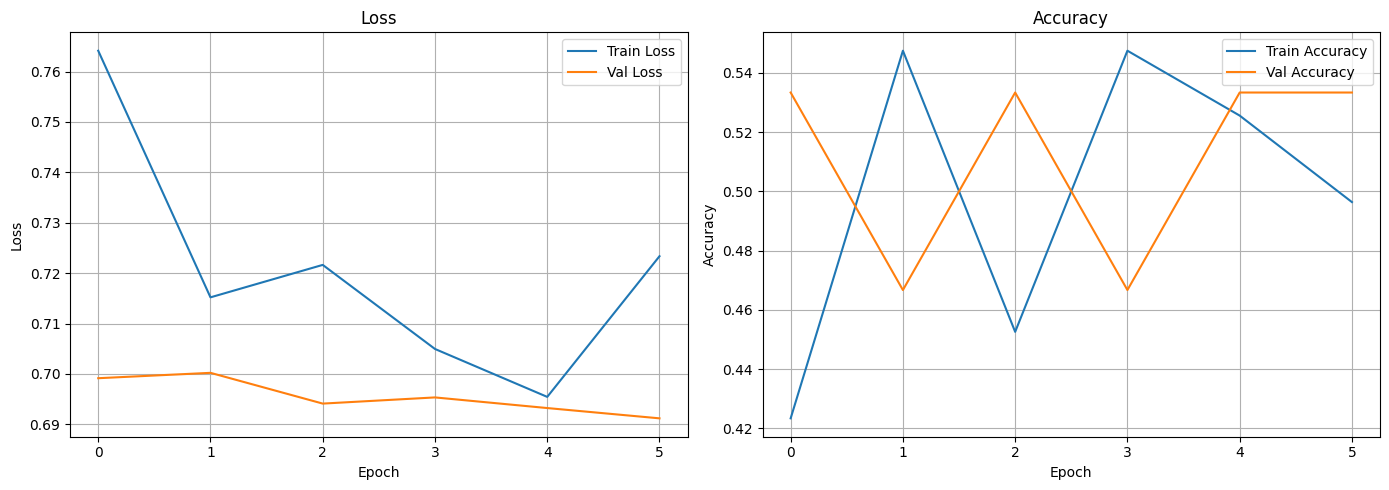

In [ ]:
fig = plot_training_history(train_losses, val_losses, train_accs, val_accs)
fig.savefig(OUTPUT_DIR / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.4 Оценка на тестовом наборе

In [ ]:
# Загружаем лучшую модель
model.load_state_dict(torch.load(OUTPUT_DIR / "best_model.pt", map_location=device))

test_loss, test_acc, test_preds, test_true, test_probs = evaluate(
    model, test_loader, criterion, device
)

metrics = compute_metrics(test_true, test_preds, test_probs, k=min(3, num_classes))

print("=" * 50)
print("TEST RESULTS")
print("=" * 50)
for name, value in metrics.items():
    print(f"  {name}: {value:.4f}")

ValueError: `y_true` is binary while y_score is 2d with 2 classes. If `y_true` does not contain all the labels, `labels` must be provided.

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(test_true, test_preds, target_names=class_names))

In [ ]:
fig = plot_confusion_matrix(test_true, test_preds, class_names, figsize=(12, 10))
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 3.5 Анализ ошибок

In [ ]:
# Per-class accuracy
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_true, test_preds)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(class_names, per_class_acc, color="steelblue")
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_title("Per-class Accuracy")
for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2, 
            f"{acc:.3f}", va="center")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "per_class_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Наиболее частые ошибки
errors = []
for i in range(len(test_true)):
    if test_true[i] != test_preds[i]:
        errors.append((class_names[test_true[i]], class_names[test_preds[i]]))

from collections import Counter
error_counts = Counter(errors).most_common(10)

print("Top-10 most common misclassifications:")
print(f"{'True':>25s} -> {'Predicted':<25s} Count")
print("-" * 60)
for (true_cls, pred_cls), count in error_counts:
    print(f"{true_cls:>25s} -> {pred_cls:<25s} {count}")

## 3.6 Сохранение результатов

In [ ]:
results = {
    "config": cfg,
    "num_classes": num_classes,
    "class_names": class_names,
    "test_metrics": {k: float(v) for k, v in metrics.items()},
    "best_val_acc": float(best_val_acc),
    "epochs_trained": len(train_losses),
    "total_params": total_params,
}

with open(OUTPUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Saved:")
print(f"  {OUTPUT_DIR / 'best_model.pt'}")
print(f"  {OUTPUT_DIR / 'results.json'}")
print(f"  {OUTPUT_DIR / 'training_history.png'}")
print(f"  {OUTPUT_DIR / 'confusion_matrix.png'}")
print(f"  {OUTPUT_DIR / 'per_class_accuracy.png'}")
print("\nDone!")

asdasd